In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FixedLocator
import pandas as pd

files = {
    'Native': '/home/mengelsl/MA-bench-framework/outputs/krylov/native2/summary_krylov.csv',
    'SME': '/home/mengelsl/MA-bench-framework/outputs/krylov/sme2/summary_krylov.csv', 
}

dfs = []

for mode, path in files.items():
    temp_df = pd.read_csv(path)
    temp_df.insert(0, 'Mode', mode)
    dfs.append(temp_df)

df_raw = pd.concat(dfs, ignore_index=True)
df_raw['total_time'] = df_raw['SpMVTime'] + df_raw['MgmtTime']

def get_median_time_run(group):
    return group.loc[(group['total_time']- group['total_time'].median()).abs().idxmin()]

group_cols = ['Mode', 'Algo', 'Matrix', 'Cores', 'NUMA', 'Arg1', 'Arg2', 'Arg3']
df_med = df_raw.groupby(group_cols, group_keys=False).apply(get_median_time_run, include_groups=False).reset_index()

df_med['ns_per_op'] = ((df_med['total_time']) * 1e9) / df_med['N_Ops']
df_med.drop(columns=['Run'], inplace=True)
df = df_med.copy()

In [54]:
df

,Mode,Algo,Matrix,Cores,NUMA,Arg1,Arg2,Arg3,SpMVTime,MgmtTime,N_Ops,Insn,Cycl,RefCycl,Cache_Miss,Stalls,PgFault,total_time,ns_per_op
0,Native,arnoldi,symmetric/Bump2911.bin,1,localalloc,8,2,10,4.02607,2.943120,75.0,6.661992e+10,2.535735e+10,1.644801e+10,3.591207e+07,1.462591e+08,10923.0,6.969190,9.292253e+07
1,Native,arnoldi,symmetric/Bump2911.bin,4,localalloc,11,2,10,4.18252,3.873610,99.0,1.021841e+11,8.031998e+10,5.209945e+10,4.679441e+07,6.425100e+08,7943.0,8.056130,8.137505e+07
2,Native,arnoldi,symmetric/Bump2911.bin,8,localalloc,11,2,10,4.21719,3.881900,99.0,1.031988e+11,1.491117e+11,9.672107e+10,5.031269e+07,1.300446e+09,7957.0,8.099090,8.180899e+07
3,Native,arnoldi,symmetric/Bump2911.bin,16,localalloc,22,2,10,4.15819,7.373800,187.0,1.983408e+11,3.150968e+11,2.251813e+15,2.251800e+15,2.513437e+09,9641.0,11.531990,6.166840e+07
4,Native,arnoldi,symmetric/Bump2911.bin,24,localalloc,26,2,10,4.07435,8.626220,219.0,2.360661e+11,4.696718e+11,3.049173e+11,1.274016e+08,3.685480e+09,10963.0,12.700570,5.799347e+07
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
535,SME,lanczos,symmetric/nd6k.bin,24,localalloc,819,2,10,4.20570,0.788883,7237.0,3.616338e+11,4.324323e+11,6.755484e+15,6.755400e+15,7.065217e+10,1076.0,4.994583,6.901455e+05
536,SME,lanczos,symmetric/nd6k.bin,32,interleave,1105,2,10,3.86036,1.132380,9811.0,4.937150e+11,5.795781e+11,3.759425e+11,5.372262e+08,1.276844e+11,1099.0,4.992740,5.088921e+05
537,SME,lanczos,symmetric/nd6k.bin,32,localalloc,1105,2,10,5.15119,1.152880,9811.0,9.007262e+15,9.007292e+15,4.733722e+11,5.355448e+08,1.320893e+11,1102.0,6.304070,6.425512e+05
538,SME,lanczos,symmetric/nd6k.bin,48,interleave,1425,2,10,4.69425,1.871890,12691.0,6.606809e+11,1.139276e+12,7.389899e+11,8.367884e+08,3.713605e+11,1151.0,6.566140,5.173855e+05


In [ ]:
df_raw[(df_raw['Algo'] == 'bicgstab') & (df_raw['Cores'] == 48) & (df_raw['Matrix'] == 'symmetric/Bump2911.bin')].sort_values(by=['Algo', 'Matrix', 'Cores', 'NUMA', 'Mode', 'Run'])

,Mode,Algo,Matrix,Cores,NUMA,Run,Arg1,Arg2,Arg3,SpMVTime,MgmtTime,N_Ops,Insn,Cycl,RefCycl,Cache_Miss,Stalls,PgFault,total_time
917,Native,bicgstab,symmetric/Bump2911.bin,48,interleave,1,169,0,0,6.38854,4.70644,169,701731594553,1657007702683,3378490513991976,3236962472938096,13820025797,8150,11.09498
1037,Native,bicgstab,symmetric/Bump2911.bin,48,interleave,2,169,0,0,6.34648,4.63774,169,701231437249,1652172559873,1071680967696,346390282,13823645474,8152,10.98422
1157,Native,bicgstab,symmetric/Bump2911.bin,48,interleave,3,169,0,0,6.34567,4.59957,169,701058139865,1650965392032,1070900480856,346567875,14675912681,8150,10.94524
1277,Native,bicgstab,symmetric/Bump2911.bin,48,interleave,4,169,0,0,6.37388,4.70462,169,701620104662,1655172939938,1073628859776,345240233,14087326340,8152,11.07850
1397,Native,bicgstab,symmetric/Bump2911.bin,48,interleave,5,169,0,0,6.35751,4.62729,169,6755473881259326,6755575608966271,13511321855092536,13510799048488576,14001277243,8149,10.98480
1605,SME,bicgstab,symmetric/Bump2911.bin,48,interleave,1,169,0,0,6.75953,6.17987,169,700505068481,1894282366144,1228736041656,460250023,630588331293,6454,12.93940
1875,SME,bicgstab,symmetric/Bump2911.bin,48,interleave,2,169,0,0,6.73644,6.23526,169,700866372940,1898496597023,1231468757328,442315510,634918858152,6452,12.97170
2145,SME,bicgstab,symmetric/Bump2911.bin,48,interleave,3,169,0,0,6.78075,6.28778,169,701137994517,1901553932917,1233454013424,468631920,636480673841,6453,13.06853
2415,SME,bicgstab,symmetric/Bump2911.bin,48,interleave,4,169,0,0,6.76295,6.34299,169,700793941617,1897911370892,1231093896528,472935077,633264211208,6452,13.10594
2685,SME,bicgstab,symmetric/Bump2911.bin,48,interleave,5,169,0,0,6.77727,6.08111,169,700771200655,1896355173227,1230082974696,454707570,633240662484,6454,12.85838


In [ ]:
df_raw[(df_raw['Algo'] == 'bicgstab') & (df_raw['Cores'] == 48) & (df_raw['Matrix'] == 'symmetric/Bump2911.bin')].sort_values(by=['Algo', 'Matrix', 'Cores', 'NUMA', 'Mode',  'Run'])

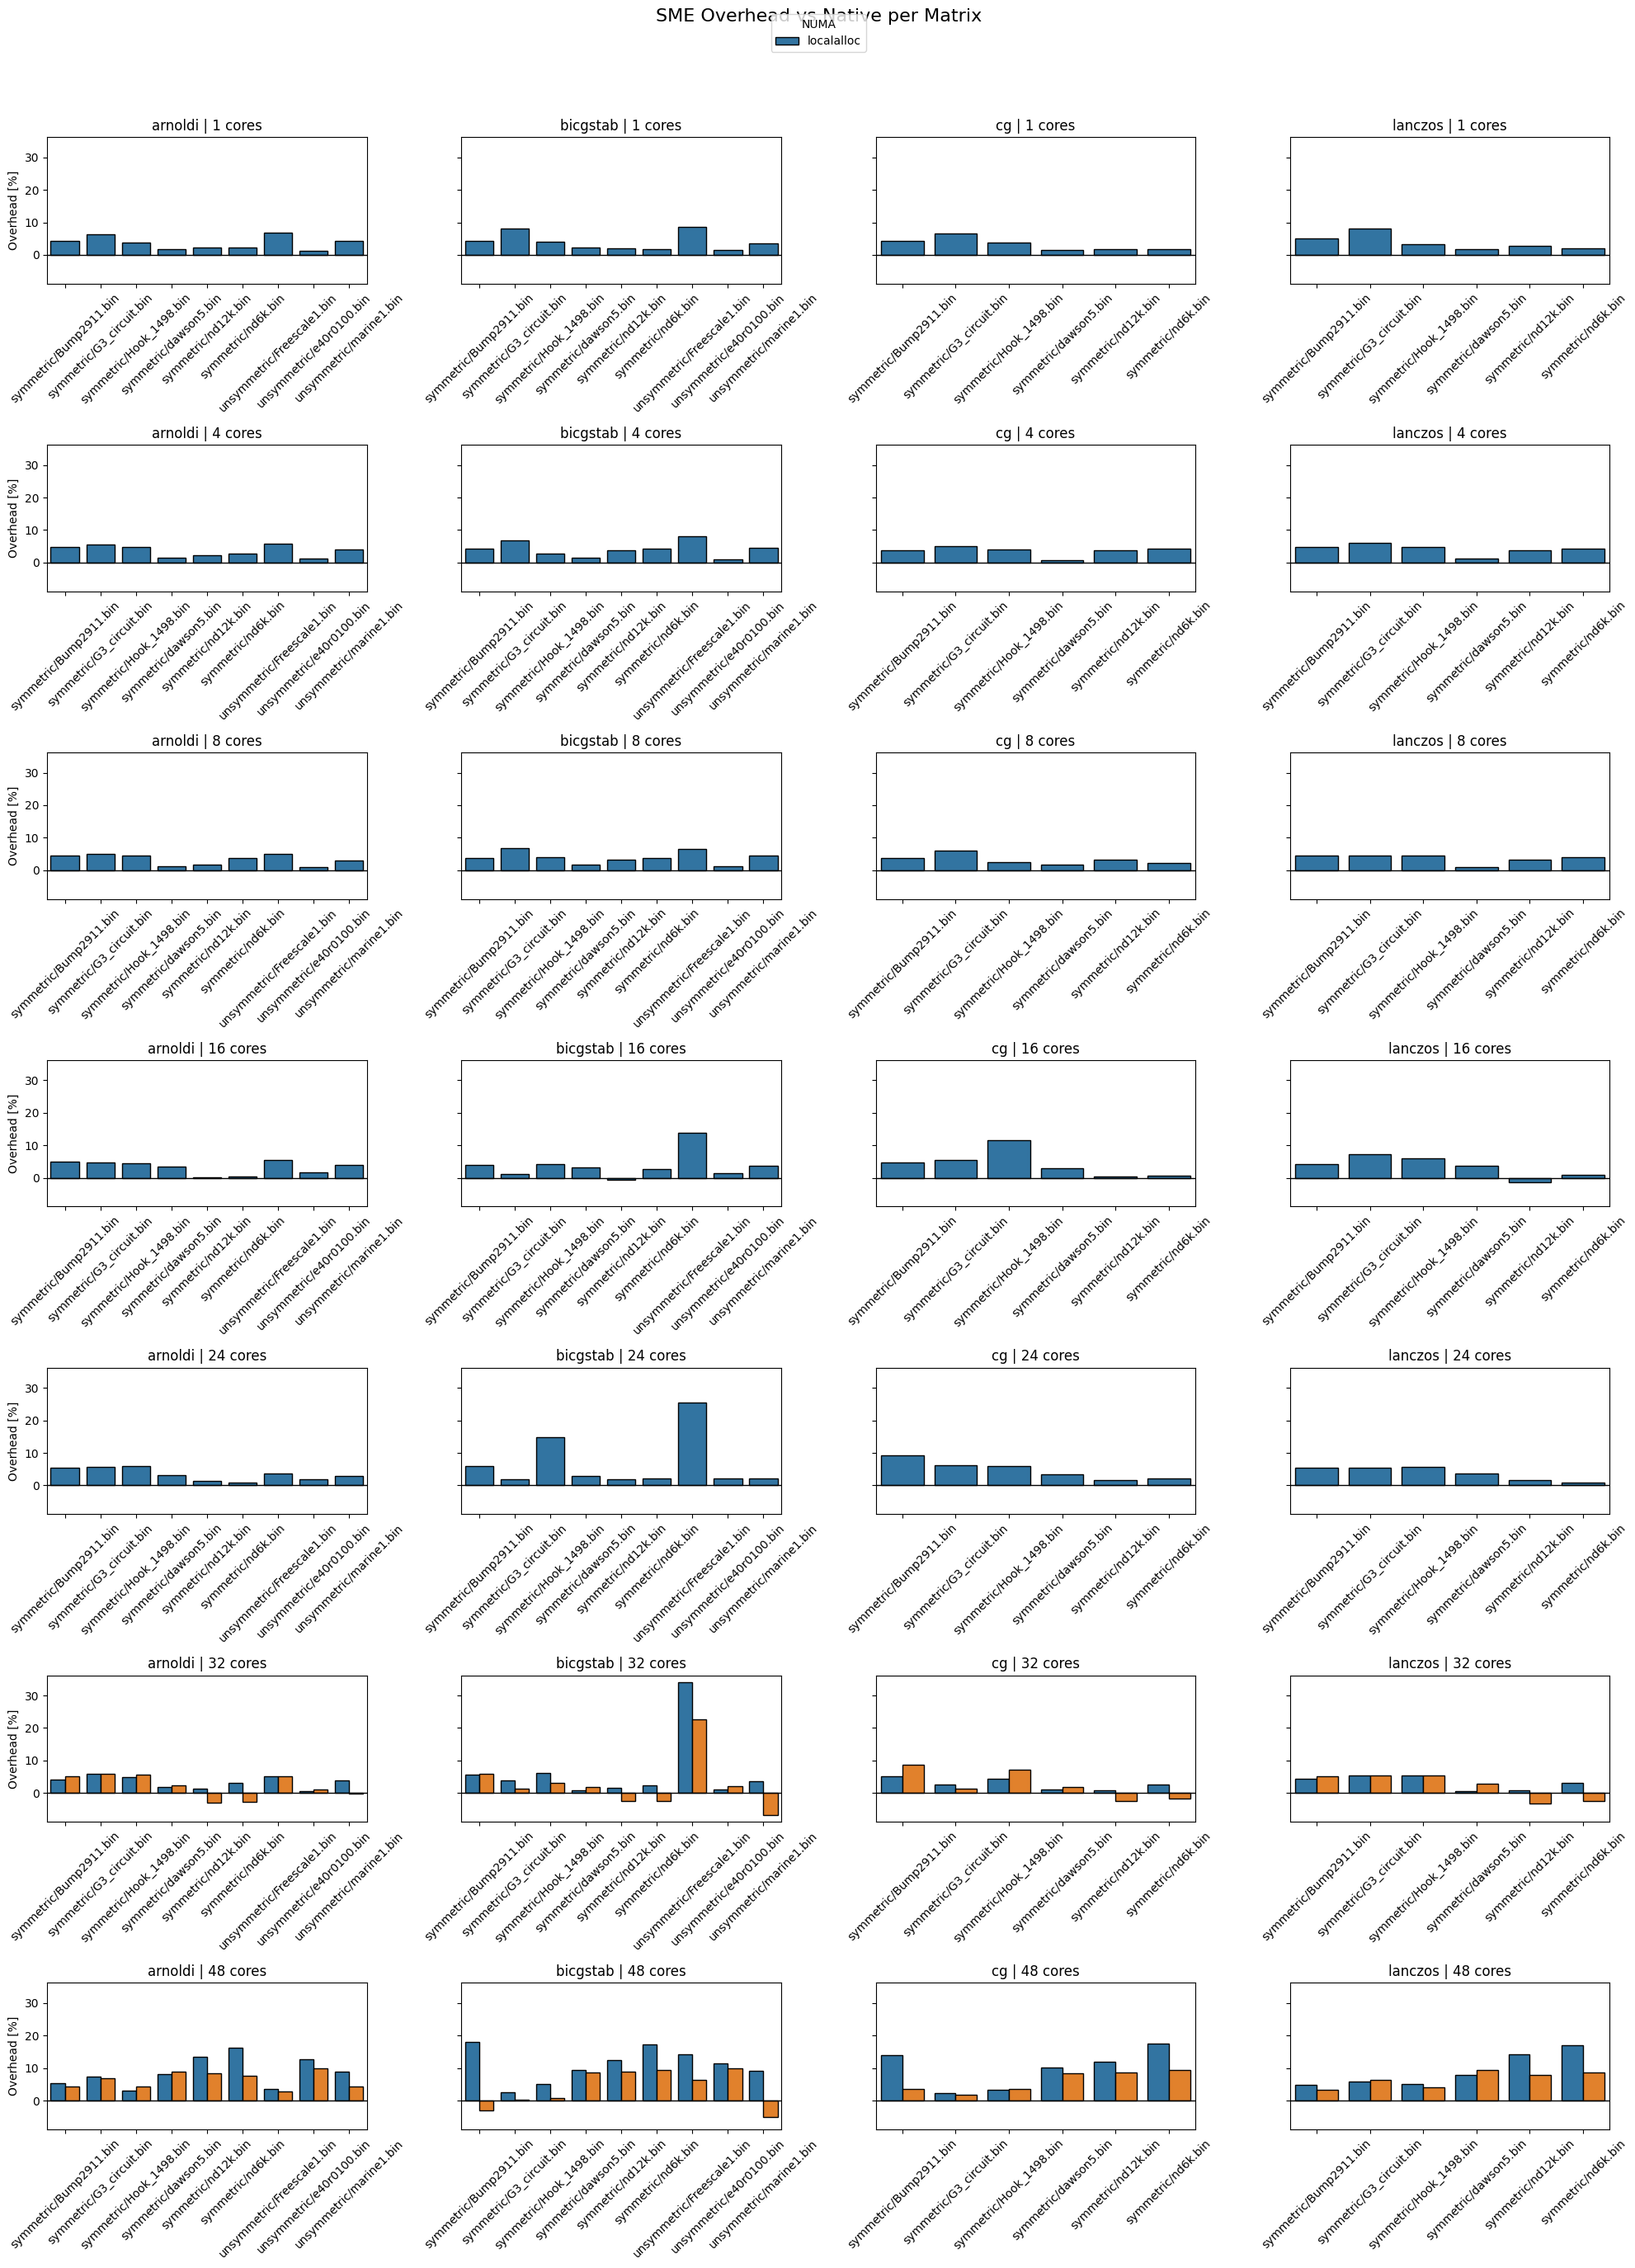

In [71]:
match_cols = ['Algo', 'Matrix', 'Cores', 'NUMA', 'Arg1', 'Arg2', 'Arg3']

native_ref = df[df['Mode'] == 'Native'][match_cols + ['ns_per_op']] .rename(columns={'ns_per_op': 'native_ns_per_op'})

sme = df[df['Mode'] == 'SME'].copy()

df_ov = sme.merge(native_ref, on=match_cols, how='inner')

df_ov = df_ov.rename(columns={'ns_per_op': 'sme_ns_per_op'})

df_ov['overhead_pct'] = (df_ov['sme_ns_per_op'] / df_ov['native_ns_per_op'] - 1) * 100

df_ov = df_ov[['Algo', 'Matrix', 'Cores', 'NUMA', 'Arg1', 'Arg2', 'Arg3', 'sme_ns_per_op', 'native_ns_per_op', 'overhead_pct']].copy()

df_plot = df_ov.sort_values(['Algo','Cores','Matrix'])

cores = sorted(df_ov['Cores'].unique())
algos = sorted(df_ov['Algo'].unique())

fig, axes = plt.subplots(len(cores), len(algos), figsize=(5*len(algos),4*len(cores)), sharey=True)

if len(cores) == 1: axes = [axes]
if len(algos) == 1: axes = [[ax] for ax in axes]

for i,c in enumerate(cores):
    for j,a in enumerate(algos):
        ax = axes[i][j]
        d = df_plot[(df_plot['Cores']==c)&(df_plot['Algo']==a)]
        if d.empty:
            ax.set_visible(False)
            continue
        sns.barplot(data=d,x='Matrix',y='overhead_pct',hue='NUMA',edgecolor='black',ax=ax)
        ax.axhline(0,color='black',linewidth=1)
        ax.set_title(f'{a} | {c} cores')
        ax.set_xlabel('')
        ax.set_ylabel('Overhead [%]' if j==0 else '')
        ax.tick_params(axis='x',rotation=45)
        if ax.get_legend(): ax.get_legend().remove()

handles, labels = axes[0][0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=2, bbox_to_anchor=(0.5,0.98), title='NUMA')
fig.suptitle('SME Overhead vs Native per Matrix', fontsize=16)
plt.tight_layout(rect=[0,0,1,0.95])
plt.show()



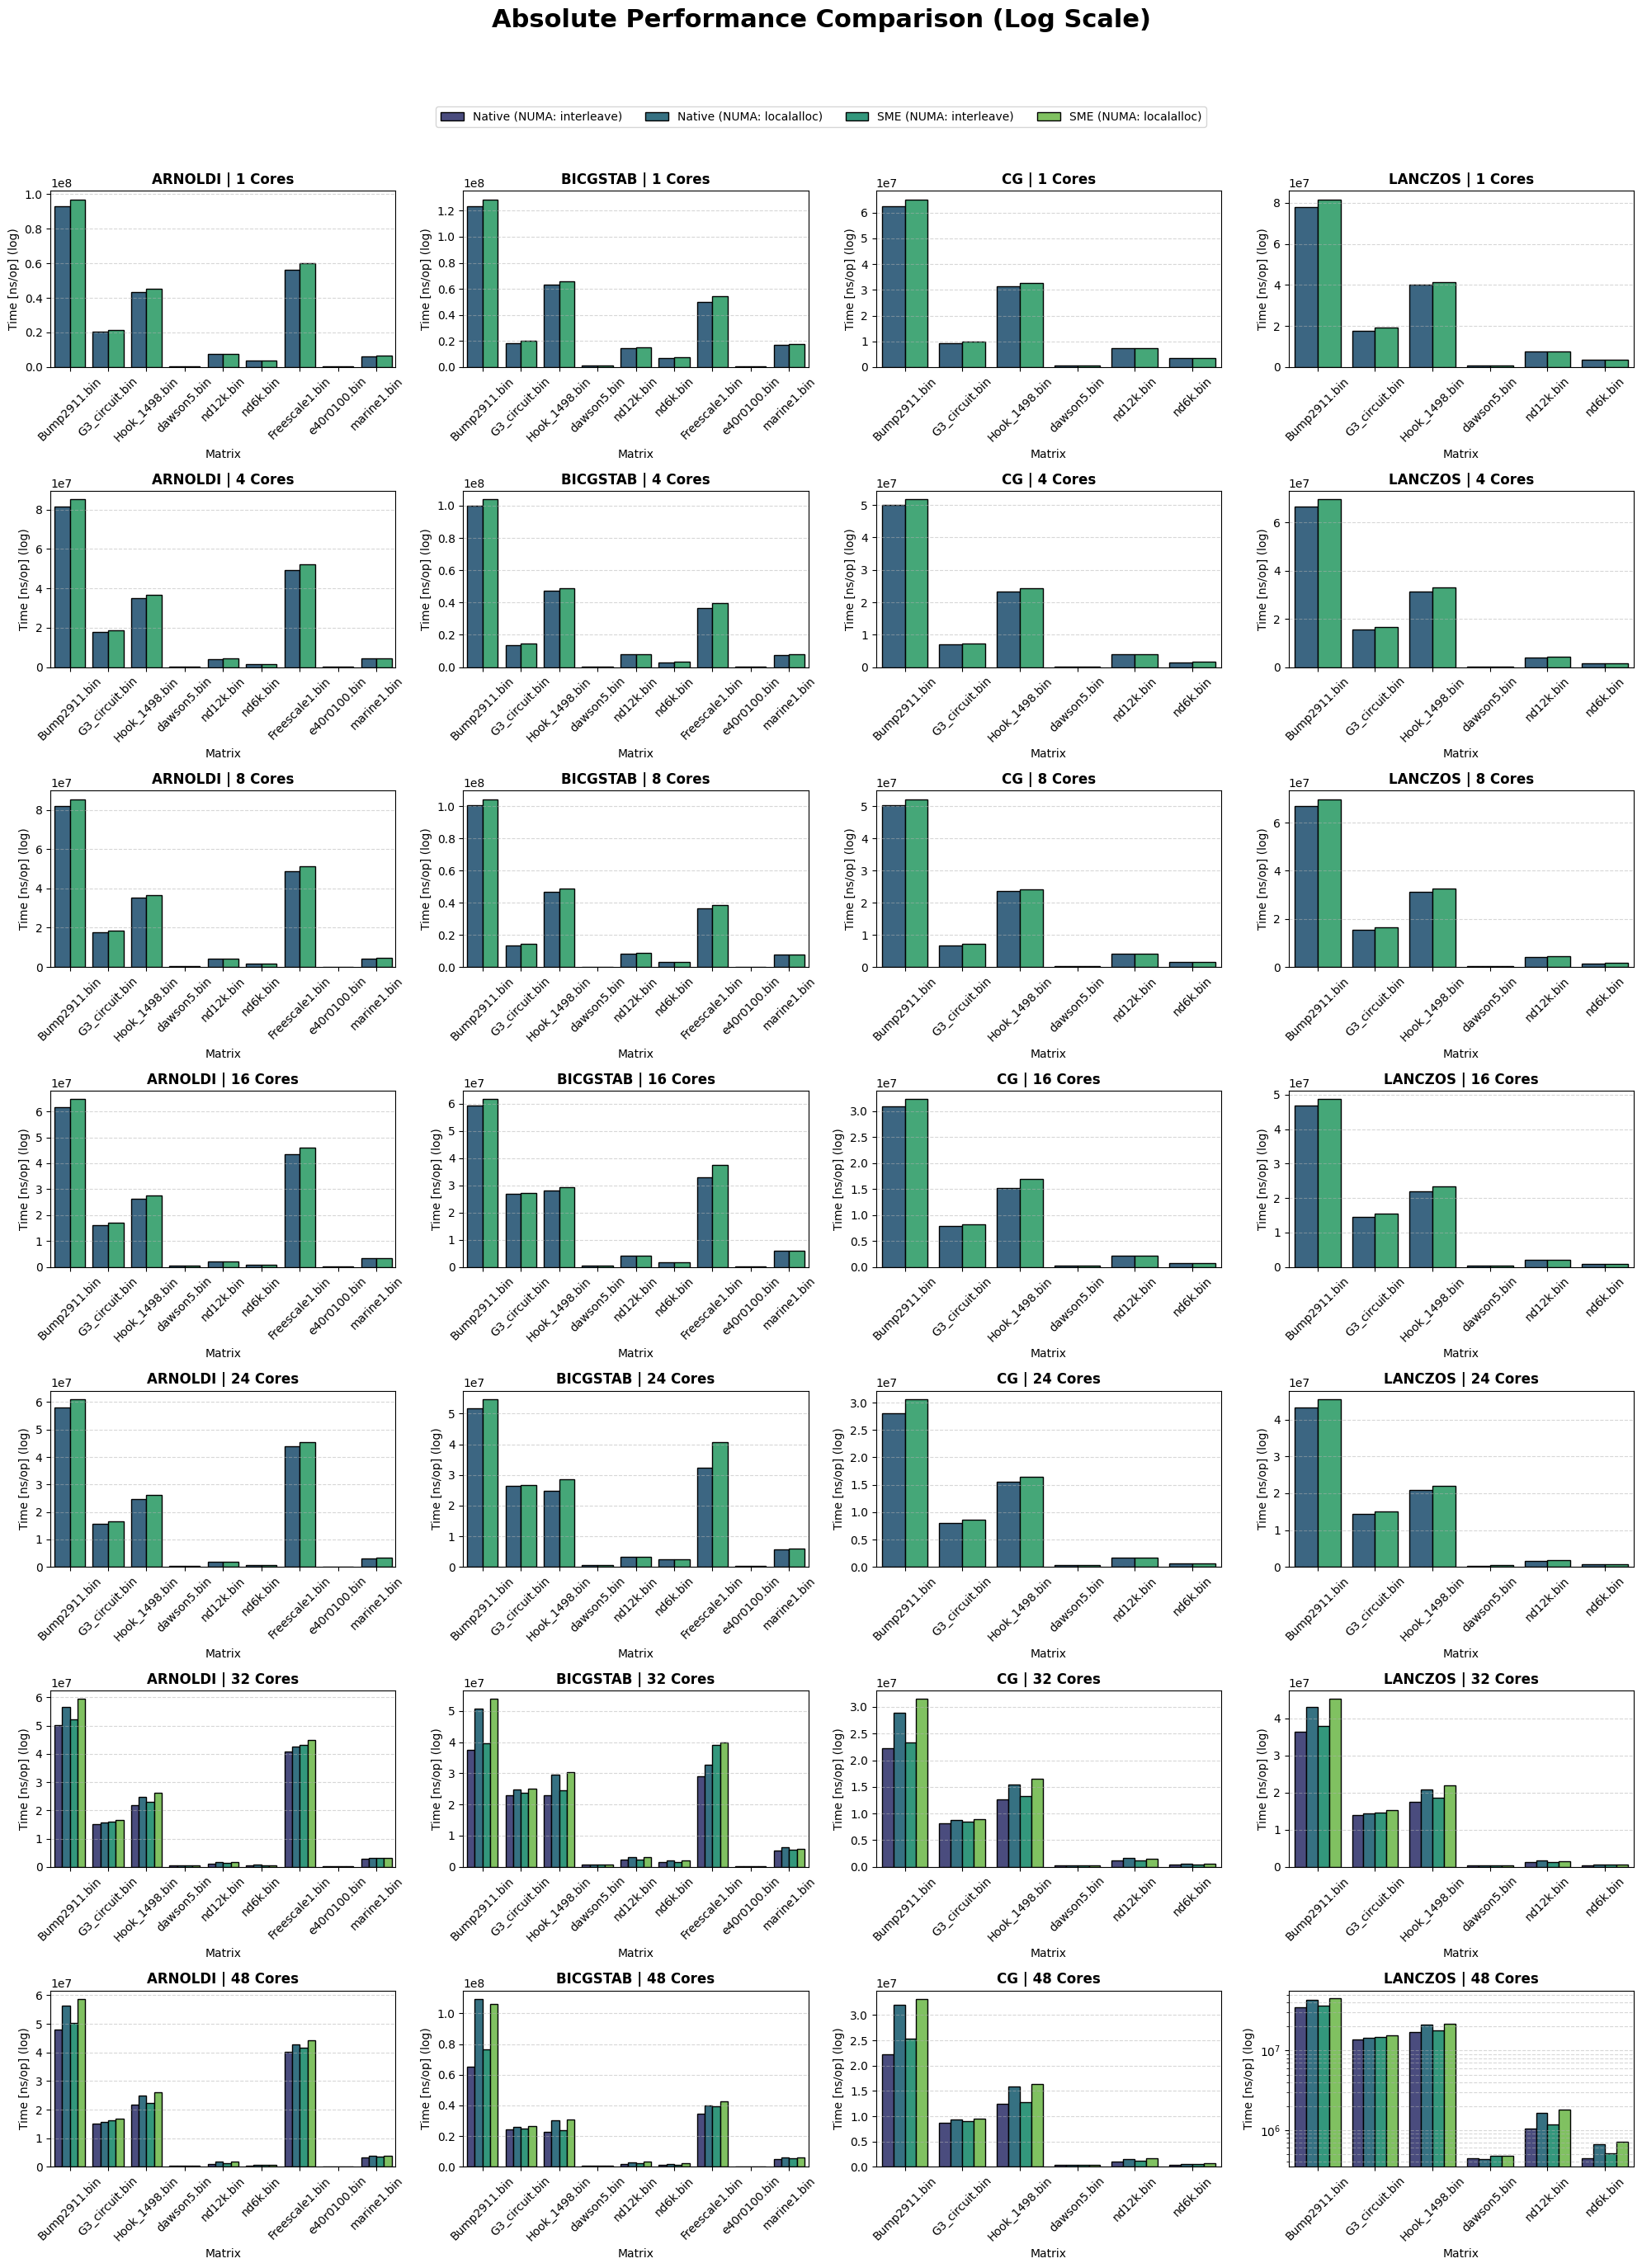

In [69]:
# 1. Vorbereitung der Daten für absolute Werte
# Wir nehmen das ursprüngliche df, nicht das diff_df
plot_abs_df = df.copy()

# Labels aufbereiten
plot_abs_df['Matrix_Label'] = plot_abs_df['Matrix'].str.split('/').str[-1]
plot_abs_df['Algo'] = plot_abs_df['Algo'].str.upper()
plot_abs_df['Legend_Label'] = plot_abs_df['Mode'] + " (NUMA: " + plot_abs_df['NUMA'] + ")"

unique_cores = sorted(plot_abs_df['Cores'].unique())
unique_algos = sorted(plot_abs_df['Algo'].unique())

# 2. Subplot-Grid
n_rows = len(unique_cores)
n_cols = len(unique_algos)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(5 * n_cols, 4 * n_rows),
    sharey=False # Hier False, da Matrizen zu unterschiedliche Laufzeiten haben
)

if n_rows == 1: axes = [axes]
if n_cols == 1: axes = [[ax] for ax in axes]

# 3. Plotten
for i, core in enumerate(unique_cores):
    for j, algo in enumerate(unique_algos):
        ax = axes[i][j]
        data = plot_abs_df[
            (plot_abs_df['Cores'] == core) & 
            (plot_abs_df['Algo'] == algo)
        ]
        
        if data.empty: continue

        sns.barplot(
            data=data,
            x='Matrix_Label',
            y='ns_per_op',
            hue='Legend_Label',
            palette='viridis', # Andere Palette zur Unterscheidung
            edgecolor='black',
            ax=ax
        )

        ax.grid(axis='y', linestyle='--', alpha=0.5, which="both")
        ax.set_title(f"{algo} | {core} Cores", fontweight='bold')
        ax.set_xlabel("Matrix")
        ax.set_ylabel("Time [ns/op] (log)")
        ax.tick_params(axis='x', rotation=45)

        if ax.get_legend():
            ax.get_legend().remove()

# 4. Globale Legende
handles, labels = ax.get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=4, bbox_to_anchor=(0.5, 0.94))

fig.suptitle("Absolute Performance Comparison (Log Scale)", fontsize=22, fontweight='bold', y=0.98)

plt.yscale('log')
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()